# Notebook 01 — Replicator vs Fermi update rule (L = 1)

**Goal:** Compare the replicator (proportional imitation) and Fermi update rules at L = 1.
Reproduces qualitatively Pereda (2016) *PRE* 94, 032314 and validates the Fermi rule
adopted for the rest of the paper.

**Structure:**
- **Part I — Simulation:** builds networks, runs sweeps, saves results to `data/`.  
  Run once (can take ~20–30 min). Results are cached; re-running loads from disk.
- **Part II — Figures:** loads CSVs, makes all plots.  
  Can be run independently at any time without re-simulating.

In [1]:
# ── Shared: imports and parameters (fast; run before Part I or Part II) ─────
import os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import model

# Simulation parameters
N        = 1000
n_rep    = 100      # set to 10 for a quick smoke test
L        = 1
lam      = 0.5     # irrelevant at L=1 (alpha=[1.0] by normalization)
K_fermi  = 0.1
b_vals   = np.round(np.linspace(1.0, 2.0, 11), 2)
th_vals  = np.round(np.linspace(0.0, 1.0, 11), 2)
NET_SEED = 0       # one fixed network per topology
SIM_SEED = 0       # base seed for replications
N_JOBS   = -1      # use all cores

# Network registry (used by both parts)
NETWORKS = [
    ('BA_z4',  'BA', 4,  'BA, $z=4$'),
    ('BA_z16', 'BA', 16, 'BA, $z=16$'),
    ('ER_z4',  'ER', 4,  'ER, $z=4$'),
    ('ER_z16', 'ER', 16, 'ER, $z=16$'),
]

os.makedirs('data',    exist_ok=True)
os.makedirs('figures', exist_ok=True)

print('b:', b_vals)
print('θ:', th_vals)

b: [1.  1.1 1.2 1.3 1.4 1.5 1.6 1.7 1.8 1.9 2. ]
θ: [0.  0.1 0.2 0.3 0.4 0.5 0.6 0.7 0.8 0.9 1. ]


---
## Part I — Simulation
*Run once to produce the CSV files in `data/`. Safe to skip if CSVs already exist.*

In [2]:
# ── Build networks ──────────────────────────────────────────────────────────
graphs = {
    key: model.build_network(topo, N, z, seed=NET_SEED)
    for key, topo, z, _ in NETWORKS
}

for key, topo, z, label in NETWORKS:
    G = graphs[key]
    k = 2 * G.number_of_edges() / G.number_of_nodes()
    d = nx.diameter(G)
    print(f"{label:12s}  N={G.number_of_nodes()}  <k>={k:.2f}  diameter={d}")

BA, $z=4$     N=1000  <k>=3.99  diameter=7
BA, $z=16$    N=1000  <k>=15.87  diameter=4
ER, $z=4$     N=979  <k>=4.11  diameter=10
ER, $z=16$    N=1000  <k>=16.21  diameter=4


In [3]:
# ── Pre-compile JIT kernels ─────────────────────────────────────────────────
model.warm_up()
print('JIT kernels compiled.')

JIT kernels compiled.


In [4]:
# ── Run sweeps and save to CSV ──────────────────────────────────────────────
def sim_csv_path(key, rule):
    return f"data/01-{key}-{rule}.csv"

for key, topo, z, label in NETWORKS:
    G  = graphs[key]
    gp, gd = model.game_csr(G)
    sp, sd = model.shells_csr(G, L)
    al     = model.geometric_kernel(L, lam)
    for rule in ('rep', 'fermi'):
        path = sim_csv_path(key, rule)
        if os.path.exists(path):
            print(f"  skip (exists): {path}")
            continue
        print(f"  running {label} — {rule} ...", flush=True)
        df = model.run_sweep(
            gp, gd, sp, sd, al,
            b_vals, th_vals,
            K=K_fermi, n_rep=n_rep,
            n_jobs=N_JOBS, base_seed=SIM_SEED,
            update_rule=rule,
        )
        df.to_csv(path, index=False)
        print(f"  saved: {path}")

print('Part I done.')

  running BA, $z=4$ — rep ...
  saved: data/01-BA_z4-rep.csv
  running BA, $z=4$ — fermi ...
  saved: data/01-BA_z4-fermi.csv
  running BA, $z=16$ — rep ...
  saved: data/01-BA_z16-rep.csv
  running BA, $z=16$ — fermi ...
  saved: data/01-BA_z16-fermi.csv
  running ER, $z=4$ — rep ...
  saved: data/01-ER_z4-rep.csv
  running ER, $z=4$ — fermi ...
  saved: data/01-ER_z4-fermi.csv
  running ER, $z=16$ — rep ...
  saved: data/01-ER_z16-rep.csv
  running ER, $z=16$ — fermi ...
  saved: data/01-ER_z16-fermi.csv
Part I done.


---
## Part II — Figures
*Loads CSVs from `data/` and produces all figures. Runs independently of Part I.*

In [2]:
# ── Load all simulation results from disk ────────────────────────────────────
data = {}
for key, topo, z, label in NETWORKS:
    for rule in ('rep', 'fermi'):
        path = f"data/01-{key}-{rule}.csv"
        data[(key, rule)] = pd.read_csv(path)
        print(f"  loaded {path}  ({len(data[(key, rule)])} rows)")

  loaded data/01-BA_z4-rep.csv  (121 rows)
  loaded data/01-BA_z4-fermi.csv  (121 rows)
  loaded data/01-BA_z16-rep.csv  (121 rows)
  loaded data/01-BA_z16-fermi.csv  (121 rows)
  loaded data/01-ER_z4-rep.csv  (121 rows)
  loaded data/01-ER_z4-fermi.csv  (121 rows)
  loaded data/01-ER_z16-rep.csv  (121 rows)
  loaded data/01-ER_z16-fermi.csv  (121 rows)


In [3]:
# ── Figure settings ──────────────────────────────────────────────────────────
import matplotlib as mpl

plt.rcParams.update({
    'font.size': 9,
    'axes.labelsize': 10,
    'axes.titlesize': 10,
    'xtick.labelsize': 8,
    'ytick.labelsize': 8,
    'figure.dpi': 120,
})

# Sequential: GnBu — consistent with notebook 02
CMAP = 'GnBu'
VMIN, VMAX = 0.0, 1.0

# Dark2 (ColorBrewer) — first 2 colors for rep/fermi
_d2 = mpl.colormaps['Dark2']
COLORS     = {'rep': _d2(0), 'fermi': _d2(1)}
LINESTYLES = {'rep': '-',    'fermi': '--'}
LABELS     = {'rep': 'Replicator', 'fermi': 'Fermi'}
LW         = 2.0

db, dt = b_vals[1] - b_vals[0], th_vals[1] - th_vals[0]
EXTENT = [b_vals[0] - db/2, b_vals[-1] + db/2,
          th_vals[0] - dt/2, th_vals[-1] + dt/2]

def rho_matrix(df):
    return (
        df.pivot(index='theta', columns='b', values='rho_mean')
          .sort_index(ascending=True)
          .values
    )

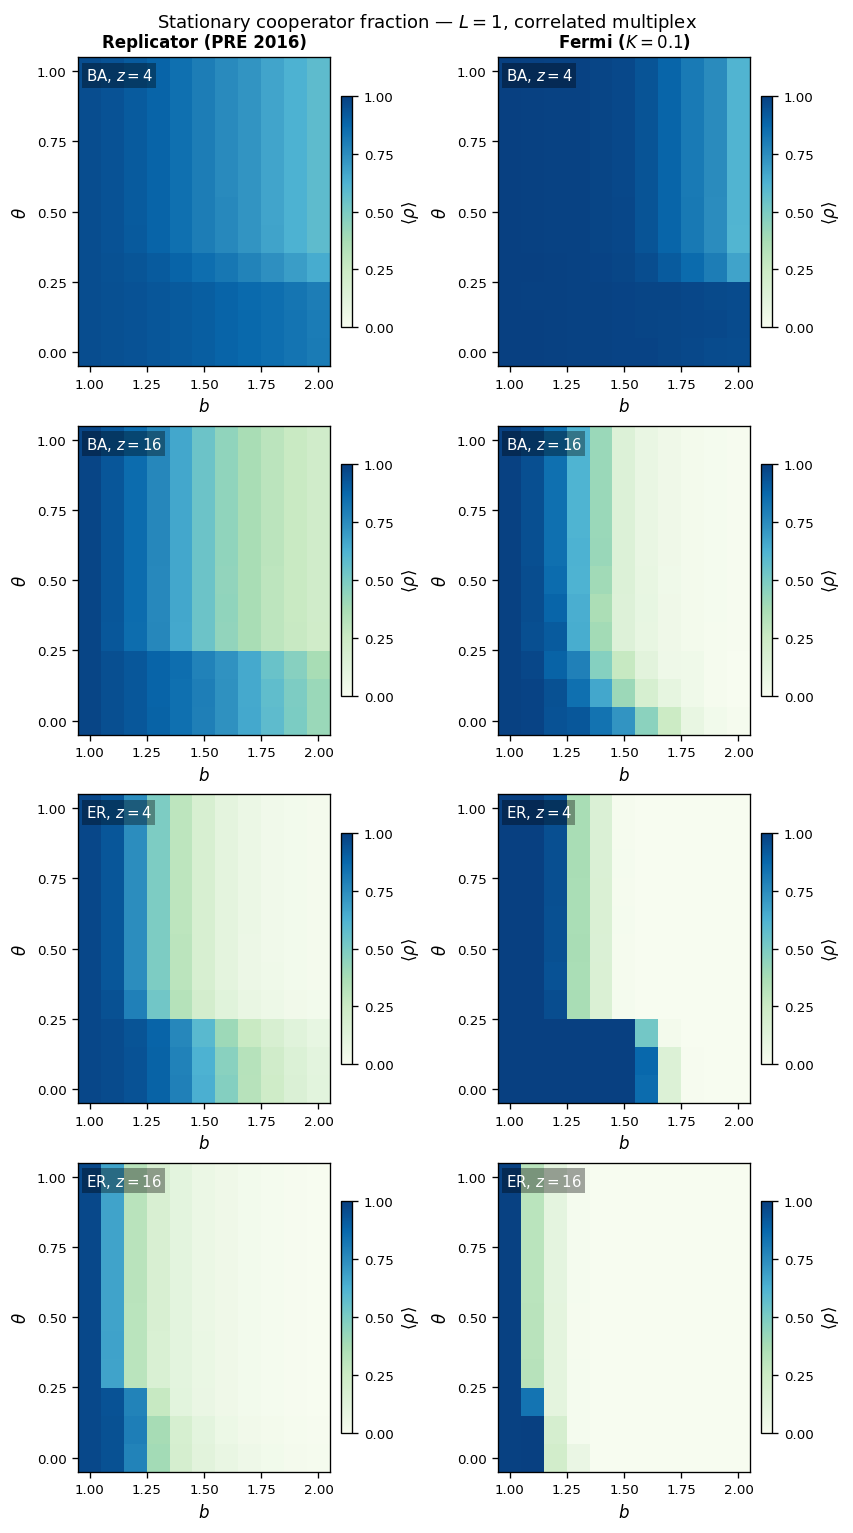

Saved figures/01-heatmaps.pdf


In [4]:
# ── Figure 1: heatmaps ⟨ρ⟩(b, θ) — 4 networks × 2 rules ────────────────────
RULES = [('rep', 'Replicator (PRE 2016)'), ('fermi', 'Fermi ($K=0.1$)')]

fig1, axes = plt.subplots(
    len(NETWORKS), len(RULES),
    figsize=(7.0, 12.5),
    constrained_layout=True,
)

for row, (key, topo, z, label) in enumerate(NETWORKS):
    for col, (rule, rule_title) in enumerate(RULES):
        ax  = axes[row, col]
        mat = rho_matrix(data[(key, rule)])
        im  = ax.imshow(
            mat, origin='lower', aspect='auto',
            vmin=VMIN, vmax=VMAX, cmap=CMAP, extent=EXTENT,
        )
        ax.set_xlabel('$b$')
        ax.set_ylabel(r'$\theta$')
        ax.xaxis.set_major_locator(mticker.MultipleLocator(0.25))
        ax.yaxis.set_major_locator(mticker.MultipleLocator(0.25))
        if row == 0:
            ax.set_title(rule_title, fontweight='bold')
        ax.text(
            0.03, 0.97, label, transform=ax.transAxes,
            va='top', color='white',
            bbox=dict(facecolor='black', alpha=0.35, pad=2, edgecolor='none'),
        )
        cb = fig1.colorbar(im, ax=ax, fraction=0.046, pad=0.03)
        cb.set_label(r'$\langle\rho\rangle$')
        cb.set_ticks([0, 0.25, 0.5, 0.75, 1.0])

fig1.suptitle('Stationary cooperator fraction — $L=1$, correlated multiplex', y=1.01)
fig1.savefig('figures/01-heatmaps.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/01-heatmaps.pdf')

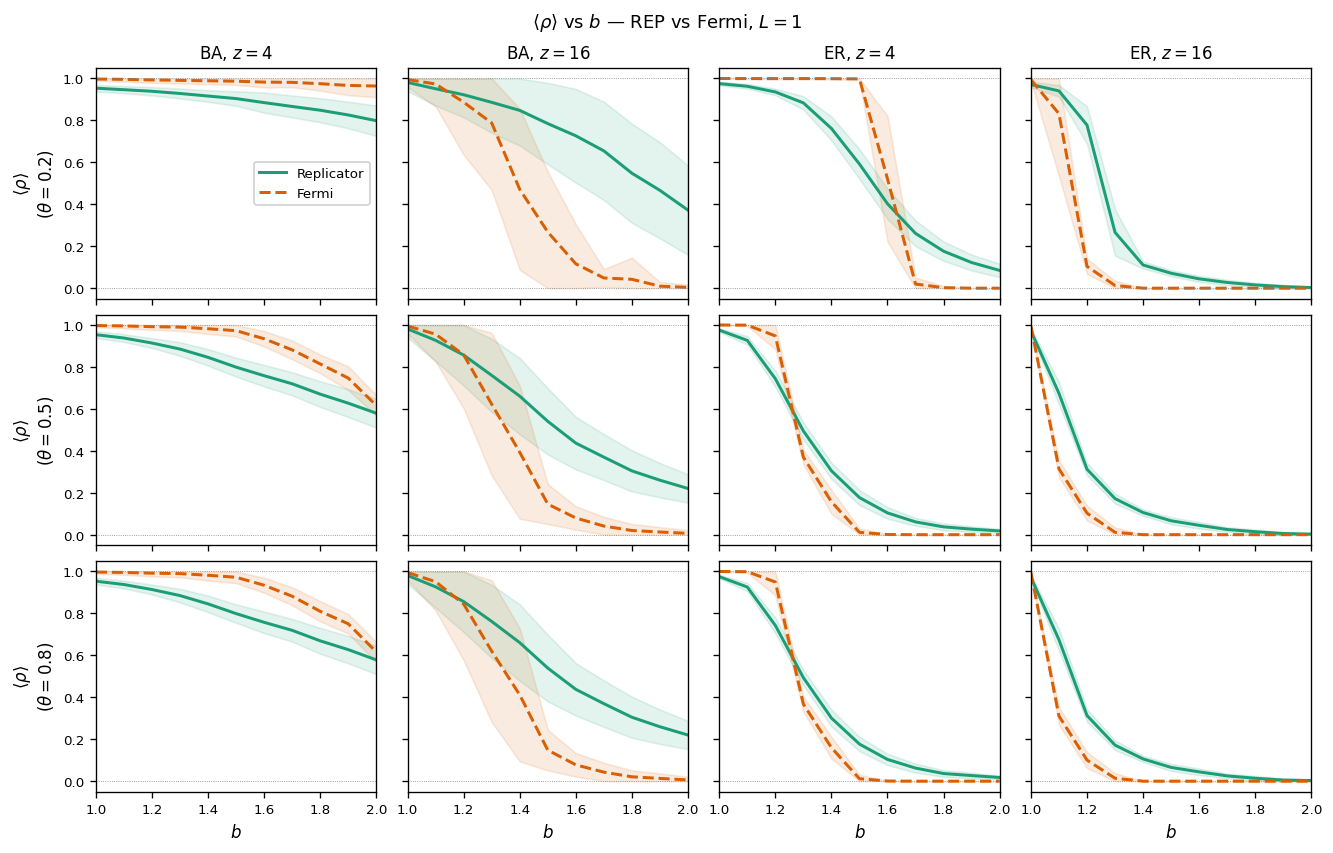

Saved figures/01-marginals.pdf


In [5]:
# ── Figure 2: marginals ⟨ρ⟩ vs b at selected θ values ───────────────────────
THETA_SHOW = [0.2, 0.5, 0.8]

fig2, axes2 = plt.subplots(
    len(THETA_SHOW), len(NETWORKS),
    figsize=(11, 7),
    constrained_layout=True,
    sharey=True, sharex=True,
)

for col, (key, topo, z, label) in enumerate(NETWORKS):
    for row, th in enumerate(THETA_SHOW):
        ax = axes2[row, col]
        for rule in ('rep', 'fermi'):
            df  = data[(key, rule)]
            sub = df[np.isclose(df['theta'], th)].sort_values('b')
            ax.plot(
                sub['b'], sub['rho_mean'],
                LINESTYLES[rule], color=COLORS[rule],
                label=LABELS[rule], lw=1.8,
            )
            ax.fill_between(
                sub['b'],
                (sub['rho_mean'] - sub['rho_std']).clip(0),
                (sub['rho_mean'] + sub['rho_std']).clip(0, 1),
                alpha=0.12, color=COLORS[rule],
            )
        if row == 0:
            ax.set_title(label)
        if col == 0:
            ax.set_ylabel(f'$\\langle\\rho\\rangle$\n($\\theta={th}$)')
        if row == len(THETA_SHOW) - 1:
            ax.set_xlabel('$b$')
        if row == 0 and col == 0:
            ax.legend(fontsize=8, framealpha=0.9)
        ax.set_xlim(1.0, 2.0)
        ax.set_ylim(-0.05, 1.05)
        ax.axhline(0, color='grey', lw=0.5, ls=':')
        ax.axhline(1, color='grey', lw=0.5, ls=':')

fig2.suptitle(r'$\langle\rho\rangle$ vs $b$ — REP vs Fermi, $L=1$')
fig2.savefig('figures/01-marginals.pdf', bbox_inches='tight')
plt.show()
print('Saved figures/01-marginals.pdf')